In [1]:
%matplotlib inline

import os, random, time, sys
from timeit import default_timer as timer
from datetime import timedelta
from datetime import datetime

import numpy as np
import scipy as sp
from scipy.spatial import distance
from scipy import signal
import pandas as pd
from tqdm import tqdm
import bct
from scipy.optimize import curve_fit

import neurogym as ngym
import torch
import torch.nn as nn

from nctpy.utils import matrix_normalization
from nctpy.metrics import ave_control
from src.neural_network import RNN, run_testing
from src.utils import normalize_x, map_kernel_to_epochs, build_reg_ken, compute_rlfp, get_weight_masks, autocorr, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='DejaVu Sans')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')

In [3]:
save_figs = True

In [4]:
# directories
datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/pytorch/model_new'
outdir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'
dt = 100
batch_size = 128
decision = 500
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
seq_len = seq_len + int((decision - 100) / dt)
seq_len = seq_len * 2
print(seq_len)

# RNN model and training parameters
rnn_model = 'rnn-tanh'
hidden_size = 200
n_runs = 25
n_epochs = 10000
lr = 0.001

# regularization parameters
reg_type = 'l2'
reg_weight = 0.001
kernel_type = 'static'
kernel_std_frac = 0.1
comet_buffer_frac = 0.1
comet_tail_frac = 0.25

mask_weights = True

52


In [5]:
if task == 'PerceptualDecisionMaking-v0':
    input_size = 3
    num_classes = 3
elif task == 'MultiSensoryIntegration-v0':
    input_size = 5
    num_classes = 3

timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir,
    'outdir': outdir,

    # data parameters
    'task': task,
    'dt': dt,
    'seq_len': seq_len,
    'batch_size': batch_size,

    # RNN model and training parameters
    'rnn_model': rnn_model,
    'hidden_size': hidden_size,
    'n_runs': n_runs,
    'n_epochs': n_epochs,
    'lr': lr,
    'mask_weights': mask_weights,

    # regularization parameters
    'reg_type': reg_type,
    'reg_weight': reg_weight,
    'kernel_type': kernel_type,
    'kernel_std_frac': kernel_std_frac,
    'comet_buffer_frac': comet_buffer_frac,
    'comet_tail_frac': comet_tail_frac,

    'env_kwargs': env_kwargs
}

file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-52-128-500_model-rnn-tanh-200-25-10000-0.001_wmask-True_reg-l2-0.001-static-0.1


# Load activity data

In [6]:
# load data
log_args = np.load(os.path.join(modeldir, file_str + '.npy'), allow_pickle=True).item()
activity = log_args['activity']
activity = activity[:, :50, :, :]

print(activity.shape)
n_timepoints = activity.shape[2]
n_trials = activity.shape[1]
trim = int(n_timepoints - (decision / 100))

(25, 50, 26, 200)


In [7]:
activity_zscore = np.zeros(activity.shape)
activity_zscore = activity_zscore[:, :, :trim, :]
print(activity_zscore.shape)

for run in tqdm(np.arange(n_runs)):
    for trial in np.arange(n_trials):
        activity_zscore[run, trial] = sp.stats.zscore(activity[run, trial, :trim], axis=0)

    activity_zscore[run] = sp.stats.zscore(activity_zscore[run], axis=0)

(25, 50, 21, 200)


100%|██████████| 25/25 [00:00<00:00, 292.04it/s]


# RLFP

In [8]:
dt_seconds = dt / 1000
num_bands = 5
sample_freq = 1 / dt_seconds
nyq_freq = sample_freq / 2
print(sample_freq, nyq_freq)

band_of_interest = 1
band_intervals = np.linspace(0, nyq_freq, num_bands + 1)
band_freq_range = band_intervals[band_of_interest - 1:band_of_interest + 1]

10.0 5.0


In [9]:
activity_reshape = np.reshape(activity_zscore.copy(), (-1, activity_zscore.shape[-1]))
print(activity_reshape.shape)
rlfp = np.zeros(hidden_size)
for neuron in tqdm(np.arange(hidden_size)):
    rlfp[neuron] = compute_rlfp(ts=activity_reshape[:, neuron], tr=dt_seconds, low=None, high=None, num_bands=num_bands, band_of_interest=band_of_interest)

(26250, 200)


100%|██████████| 200/200 [00:00<00:00, 2284.51it/s]


/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

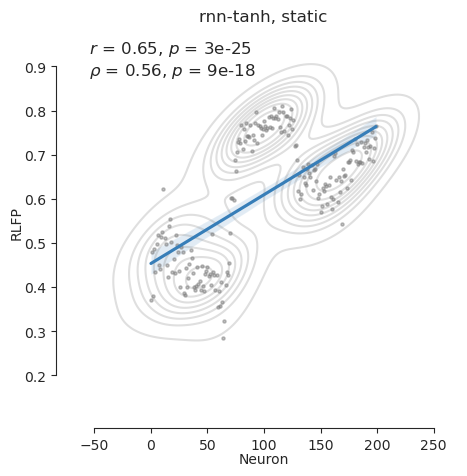

In [10]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
my_reg_plot(np.arange(hidden_size), rlfp, 'Neuron', 'RLFP', ax=ax, fontsize=12, annotate='both')
ax.set_title('{:}, {:}'.format(rnn_model, kernel_type))

if save_figs:
    f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'rlfp')), dpi=300, bbox_inches='tight', pad_inches=0.01)

# Autocorrelation, tau

In [11]:
# The exponential decay function
def exp_decay(x, tau, init):
    return init*np.e**(-x/tau)

In [12]:
tau = np.zeros((n_runs, n_trials, hidden_size))

for run in tqdm(np.arange(n_runs)):
    for trial in np.arange(n_trials):
        for neuron in np.arange(hidden_size):
            try:
                t_ac, ac = autocorr(activity[run, trial, :, neuron], max_lag=trim)
                popt, pcov = curve_fit(exp_decay, t_ac, ac)
                fit_tau, fit_init = popt
                tau[run, trial, neuron] = fit_tau
            except:
                tau[run, trial, neuron] = np.nan

  0%|          | 0/25 [00:00<?, ?it/s]/tmp/ipykernel_54508/3260128698.py:3: RuntimeWarning: overflow encountered in power
  return init*np.e**(-x/tau)
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
100%|██████████| 25/25 [01:25<00:00,  3.41s/it]


/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lindenmp/miniconda3/envs/neuro_rnn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprec

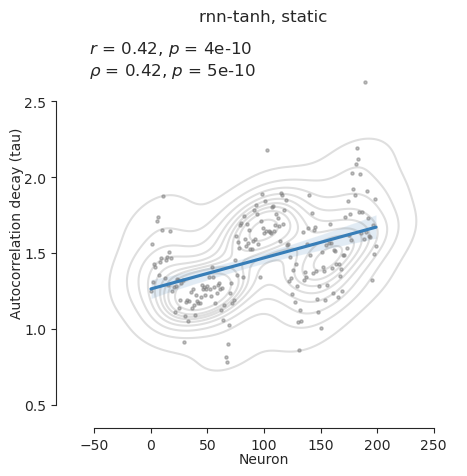

In [13]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
my_reg_plot(np.arange(hidden_size), np.nanmean(np.nanmean(tau, axis=0), axis=0), 'Neuron', 'Autocorrelation decay (tau)', ax=ax, fontsize=12, annotate='both')
ax.set_title('{:}, {:}'.format(rnn_model, kernel_type))

if save_figs:
    f.savefig(os.path.join(outdir, '{0}_{1}.png'.format(file_str, 'tau')), dpi=300, bbox_inches='tight', pad_inches=0.01)